In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
retail = pd.read_csv("Retail_Feature_Engineered.csv")

retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

monthly_sales = (
    retail
    .groupby(retail["InvoiceDate"].dt.to_period("M"))["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["ds", "y"]

monthly_sales["ds"] = monthly_sales["ds"].dt.to_timestamp()

print(monthly_sales)
print("\nShape:", monthly_sales.shape)

           ds            y
0  2009-12-01   683504.010
1  2010-01-01   555802.672
2  2010-02-01   504558.956
3  2010-03-01   696978.471
4  2010-04-01   591982.002
5  2010-05-01   597833.380
6  2010-06-01   636371.130
7  2010-07-01   589736.170
8  2010-08-01   602224.600
9  2010-09-01   829013.951
10 2010-10-01  1033112.010
11 2010-11-01  1166460.022
12 2010-12-01   310656.370

Shape: (13, 2)


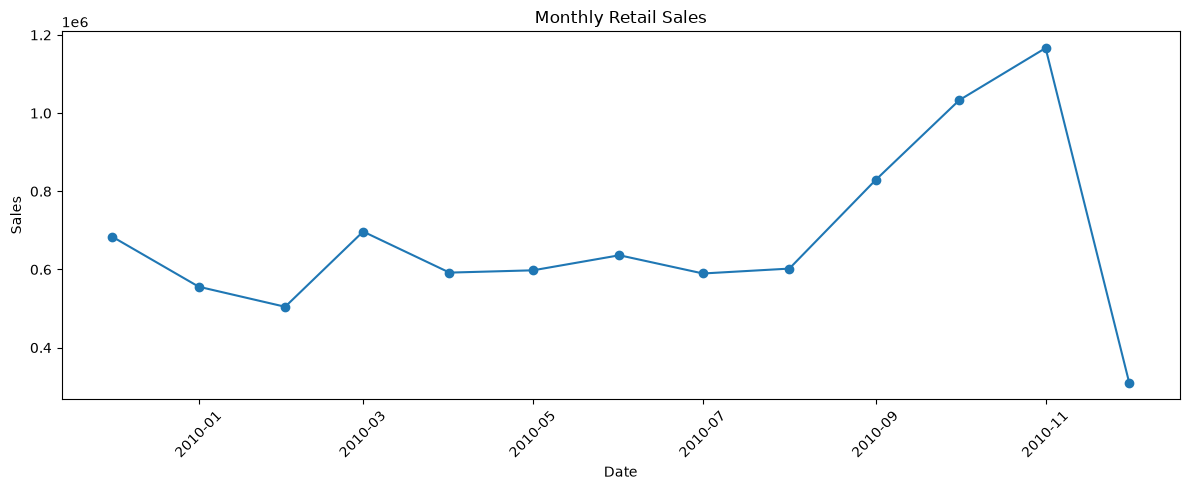

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["ds"],
    monthly_sales["y"],
    marker="o"
)

plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform(
    monthly_sales[["y"]]
)

print(scaled_sales[:5])
print("Shape:", scaled_sales.shape)

[[0.43566961]
 [0.28645157]
 [0.22657368]
 [0.45141441]
 [0.32872684]]
Shape: (13, 1)


In [32]:
lookback = 3

X = []
y = []

for i in range(lookback, len(scaled_sales)):
    X.append(scaled_sales[i-lookback:i, 0])
    y.append(scaled_sales[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 3)
y shape: (10,)


In [33]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 3, 1)
y shape: (10,)


In [34]:
test_size = 2

X_train = X[:-test_size]
X_test = X[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8, 3, 1)
X_test : (2, 3, 1)
y_train: (8,)
y_test : (2,)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.1376 - val_loss: 0.5096
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.1229 - val_loss: 0.4716
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1033 - val_loss: 0.4351
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0850 - val_loss: 0.4007
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0667 - val_loss: 0.3675
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0543 - val_loss: 0.3359
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0485 - val_loss: 0.3059
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0354 - val_loss: 0.2779
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0210 - val_loss: 0.2516
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.0168 - val_loss: 0.2275
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0147 - val_loss: 0.2056
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0098 - val_loss: 0.1855


In [37]:
y_pred = model.predict(X_test)

print("Predicted shape:", y_pred.shape)
print("Predictions:", y_pred.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted shape: (2, 1)
Predictions: [0.46219456 0.5783663 ]


In [38]:
import numpy as np

y_pred_flat = y_pred.flatten()

print("Actual values:   ", y_test)
print("Predicted values:", y_pred_flat)

Actual values:    [1. 0.]
Predicted values: [0.46219456 0.5783663 ]


In [39]:


from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_flat))
mae = mean_absolute_error(y_test, y_pred_flat)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.5584542248778893
MAE: 0.5580858588218689


In [40]:
# Convert predictions back to original sales scale
y_pred_original = scaler.inverse_transform(
    y_pred.reshape(-1, 1)
).flatten()

y_test_original = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

print("Actual sales:   ", y_test_original)
print("Predicted sales:", y_pred_original)

Actual sales:    [1166460.022  310656.37 ]
Predicted sales: [706204.1 805624.3]


In [41]:
print("Number of months:", len(monthly_sales))
print(monthly_sales[["ds", "y"]].head())
print(monthly_sales[["ds", "y"]].tail())

Number of months: 13
          ds           y
0 2009-12-01  683504.010
1 2010-01-01  555802.672
2 2010-02-01  504558.956
3 2010-03-01  696978.471
4 2010-04-01  591982.002
           ds            y
8  2010-08-01   602224.600
9  2010-09-01   829013.951
10 2010-10-01  1033112.010
11 2010-11-01  1166460.022
12 2010-12-01   310656.370
